In [1]:
import pandas as pd, numpy as np, xarray as xr, rioxarray as rxr, glob, re, os

# --- Load daily precip ---
precip = pd.read_csv(r"precip_weatherapi\precip_daily_Tambokarkas.csv",
                     parse_dates=["date"])
precip = precip.sort_values("date")

# --- Load 15d NDVI rasters and stack ---
S2_DIR = r"G:\Mi unidad\GEE_Biweekly_S2"
files = sorted(glob.glob(os.path.join(S2_DIR, "*_S2_Indices.tif")))

def parse_date(fp):
    m = re.search(r"(\d{8})_S2", os.path.basename(fp))
    return pd.to_datetime(m.group(1), format="%Y%m%d") if m else None

stack = []
times = []
for f in files:
    t = parse_date(f)
    if t is None: continue
    da = rxr.open_rasterio(f).isel(band=0).squeeze()   # NDVI band
    da = da.assign_coords(time=t).expand_dims("time")
    stack.append(da)
    times.append(t)

ndvi = xr.concat(stack, dim="time").sortby("time")
ndvi.name = "NDVI"


In [4]:
thr = precip["prcp"].quantile(0.8)
precip["is_pulse"] = precip["prcp"] > thr

# Identify pulse events
precip["group"] = (precip["is_pulse"] != precip["is_pulse"].shift()).cumsum()
pulses = (precip[precip["is_pulse"]]
          .groupby("group")
          .agg(start=("date","min"), end=("date","max"),
               total_mm=("prcp","sum"))).reset_index(drop=True)
print(pulses.head())

       start        end  total_mm
0 2022-01-04 2022-01-04       6.3
1 2022-01-07 2022-01-08      19.4
2 2022-01-12 2022-01-12       6.3
3 2022-01-18 2022-01-18       9.5
4 2022-01-21 2022-01-23      40.5


In [15]:
# ============================================================
# Hex-based rain→NDVI response and early-detection thresholds
# ============================================================
# What it does:
# - Reads your AOI hexes (existing file), daily precip CSV, S2 NDVI rasters
# - Builds per-hex NDVI time series (mean), interpolates to daily
# - Computes:
#    (A) Rain-Response Coefficient (RRC): dNDVI(15d)/mm
#    (B) Pulse metrics: TR (recovery days), EL (ΔNDVI/mm), PE (stress days)
#    (C) Dry-spell threshold D*: consecutive dry days after which NDVI ↓
# - Exports per-hex metrics (CSV) and a GPKG with current alert status
#
# Requirements: rioxarray, rasterio, xarray, pandas, numpy, geopandas, rasterstats, shapely
# ============================================================

import os, re, glob, math, warnings
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Polygon
import rioxarray as rxr
from rasterstats import zonal_stats

warnings.filterwarnings("ignore", category=UserWarning)

# ----------------------
# CONFIG (EDIT THESE)
# ----------------------
S2_DIR       = r"G:\Mi unidad\GEE_Biweekly_S2"   # your S2 biweekly indices (NDVI is band 1)
HEX_PATH     = r"./results/AOI_hexes_1km.geojson"   # your existing hex grid file
PRECIP_DAILY = r"./precip_weatherapi\precip_daily_Tambokarkas.csv"  # columns: date,prcp
OUT_DIR      = r"./outputs/rain_ndvi_hex"
SECTOR_NAME  = "Tambokarkas"                     # used in filenames

# Analysis params
NDVI_BAND_IDX_RS = 1      # rasterstats band index is 1-based; NDVI is the 1st band in your S2 export
DRY_MM           = 1.0    # dry-day threshold (mm). Change to 0.5 if needed
PULSE_Q          = 0.80   # rainfall pulse threshold = daily prcp quantile (e.g. top 20%)
BASELINE_DAYS    = 30     # NDVI baseline window before pulse
LOOKAHEAD_DAYS   = 60     # NDVI window after pulse
DNDT_FWD_DAYS    = 15     # forward horizon for NDVI change (for RRC and D* logic)

os.makedirs(OUT_DIR, exist_ok=True)

# ----------------------
# Helpers
# ----------------------
def parse_date_from_s2(fp):
    m = re.search(r"(\d{8})_S2", os.path.basename(fp))
    return pd.to_datetime(m.group(1), format="%Y%m%d") if m else None

def load_hexes(hex_path, target_crs):
    hexes = gpd.read_file(hex_path)
    if hexes.crs is None:
        # assume hexes were created in same CRS as rasters if missing (EPSG:32719 typical)
        raise ValueError("HEX file has no CRS. Please set it in your file.")
    if str(hexes.crs) != str(target_crs):
        hexes = hexes.to_crs(target_crs)
    if "hex_id" not in hexes.columns:
        hexes["hex_id"] = np.arange(len(hexes))
    return hexes

def stack_sample_dates(s2_dir):
    files = sorted(glob.glob(os.path.join(s2_dir, "*_S2_Indices.tif")))
    out = []
    for fp in files:
        t = parse_date_from_s2(fp)
        if t is not None:
            out.append((t, fp))
    if not out:
        raise RuntimeError("No S2 files found with pattern '*_S2_Indices.tif'.")
    return pd.DataFrame(out, columns=["date","path"]).sort_values("date")

def hex_mean_ndvi_time_series(hexes, s2_df, band_index=1, nodata_val=None):
    """Return long DataFrame: [date, hex_id, ndvi]"""
    rows = []
    for _, row in s2_df.iterrows():
        fp, t = row["path"], row["date"]
        zs = zonal_stats(
            hexes,
            fp,
            band=band_index,
            stats=["mean"],
            nodata=nodata_val,
            all_touched=False,
        )
        for i, st in enumerate(zs):
            rows.append({"date": t, "hex_id": int(hexes.iloc[i]["hex_id"]), "ndvi": st.get("mean", np.nan)})
    df = pd.DataFrame(rows).dropna(subset=["ndvi"])
    return df

def interp_daily_per_hex(df_hex_ndvi, precip_dates):
    """Interpolate NDVI to daily for each hex using time interpolation across your biweekly dates."""
    # Build full daily index covering precip range
    dmin, dmax = precip_dates.min(), precip_dates.max()
    daily_idx = pd.date_range(dmin, dmax, freq="D")

    out = []
    for hid, sub in df_hex_ndvi.groupby("hex_id"):
        ts = (sub.set_index("date")["ndvi"]
                .sort_index()
                .reindex(daily_idx)  # add all days (NaN in between)
                .interpolate(method="time", limit_area="inside"))  # NDVI only is interpolated
        out.append(pd.DataFrame({"date": ts.index, "hex_id": hid, "ndvi_daily": ts.values}))
    daily = pd.concat(out, ignore_index=True)
    return daily.dropna(subset=["ndvi_daily"])

def find_pulses(precip_df, q=PULSE_Q):
    """Return DataFrame with rainfall pulse events: start, end, total_mm."""
    p = precip_df.copy()
    thr = p["prcp"].quantile(q)
    p["wet"] = p["prcp"] > thr
    p["grp"] = (p["wet"] != p["wet"].shift()).cumsum()
    pulses = (p[p["wet"]]
              .groupby("grp")
              .agg(start=("date","min"),
                   end=("date","max"),
                   total_mm=("prcp","sum"))).reset_index(drop=True)
    return pulses

def event_metrics_for_hex(daily_ndvi, pulses, baseline_days=BASELINE_DAYS,
                          lookahead_days=LOOKAHEAD_DAYS):
    """Compute TR/EL/PE per event for one hex; returns list of dicts."""
    # daily_ndvi: DataFrame [date, ndvi_daily]
    recs = []
    s = daily_ndvi.set_index("date")["ndvi_daily"].sort_index()
    for _, ev in pulses.iterrows():
        start, end, total = ev["start"], ev["end"], ev["total_mm"]
        base = s.loc[start - pd.Timedelta(days=baseline_days): start - pd.Timedelta(days=1)]
        if base.empty: 
            continue
        baseline = base.median()

        after = s.loc[start: start + pd.Timedelta(days=lookahead_days)]
        if after.empty:
            continue
        diff = after - baseline
        # Peak response
        ndvi_max = diff.max()
        t_peak = (diff.idxmax() - start).days if pd.notna(diff.idxmax()) else np.nan
        # Recovery time: first day NDVI >= baseline
        recov = after[after >= baseline]
        tr = (recov.index[0] - start).days if len(recov) else np.nan
        # Persistence of stress: days NDVI < baseline
        pe = int((after < baseline).sum())
        # Elasticity (ΔNDVI per mm)
        el = (ndvi_max / total) if total and np.isfinite(total) else np.nan
        recs.append({"TR": tr, "EL": el, "PE": pe})
    return recs

def rain_response_coefficient(daily_ndvi, daily_precip, horizon_days=DNDT_FWD_DAYS):
    """
    RRC: slope of ΔNDVI_forward(horizon) vs cumulative precip over the same horizon.
    Returns slope (NDVI / mm) and r (Spearman) for robustness.
    """
    s = daily_ndvi.set_index("date")["ndvi_daily"].sort_index()
    p = daily_precip.set_index("date")["prcp"].sort_index()

    # ΔNDVI forward
    ndvi_fwd = (s.shift(-horizon_days) - s).dropna()
    # Accumulated precip over [t, t+horizon]
    prcp_h = p.rolling(window=horizon_days, min_periods=int(horizon_days*0.6)).sum().shift(-horizon_days+1)
    # Align
    df = pd.concat([ndvi_fwd.rename("dndvi"), prcp_h.rename("mm")], axis=1).dropna()
    if len(df) < 20 or df["mm"].std() == 0:
        return np.nan, np.nan
    # Simple slope
    slope = np.cov(df["mm"], df["dndvi"], ddof=0)[0,1] / np.var(df["mm"], ddof=0)
    # Spearman correlation as sanity
    rho = df["mm"].rank().corr(df["dndvi"].rank())
    return float(slope), float(rho)

def dryness_counter_series(daily_precip, dry_mm=DRY_MM):
    """Return series of consecutive dry days up to each day."""
    p = daily_precip.copy()
    p["dry"] = p["prcp"] < dry_mm
    cnt = []
    c = 0
    for d, row in p.iterrows():
        if row["dry"]:
            c += 1
        else:
            c = 0
        cnt.append(c)
    return pd.Series(cnt, index=p.index, name="dry_days")

def dryspell_threshold_Dstar(daily_ndvi, daily_precip, horizon_days=DNDT_FWD_DAYS, dry_mm=DRY_MM,
                             max_consider_days=60):
    """
    D*: smallest consecutive dry-day length D such that mean ΔNDVI_forward(horizon) <= 0.
    Uses daily precip as-is; NDVI is interpolated daily.
    """
    s = daily_ndvi.set_index("date")["ndvi_daily"].sort_index()
    p = daily_precip.set_index("date")[["prcp"]].sort_index()
    p["dry_days"] = dryness_counter_series(p, dry_mm=dry_mm)

    # ΔNDVI forward
    dndvi = (s.shift(-horizon_days) - s).rename("dndvi").dropna()
    df = p.join(dndvi, how="inner").dropna()
    if df.empty:
        return np.nan, pd.DataFrame()

    # Mean ΔNDVI by dry-day length
    grp = (df[df["dry_days"] <= max_consider_days]
             .groupby("dry_days")["dndvi"].mean())
    # Find crossing point
    Dstar_candidates = grp[grp <= 0].index
    if len(Dstar_candidates) == 0:
        Dstar = np.nan
    else:
        Dstar = int(Dstar_candidates.min())
    return Dstar, grp.reset_index().rename(columns={"dndvi":"mean_dndvi"})

# ----------------------
# Load data
# ----------------------
# 1) Sample one raster to get CRS and align hexes
s2_df = stack_sample_dates(S2_DIR)
sample = rxr.open_rasterio(s2_df.iloc[0]["path"])
RASTER_CRS = sample.rio.crs

# 2) Hex grid (your existing file), reproject to raster CRS if needed
hexes = load_hexes(HEX_PATH, RASTER_CRS)
print(f"Loaded {len(hexes)} hexes.")

# 3) Daily precipitation (as-is)
precip = (
    pd.read_csv(PRECIP_DAILY, encoding="utf-8-sig")  # handles BOM if present
    .rename(columns=lambda c: c.strip().lower())     # remove spaces, lowercase headers
)
if "date" not in precip.columns:
    raise ValueError(f"CSV columns found: {precip.columns.tolist()} — expected 'date' and 'prcp'")
precip["date"] = pd.to_datetime(precip["date"], errors="coerce")
precip = precip.dropna(subset=["date", "prcp"]).sort_values("date").reset_index(drop=True)

# 4) Per-hex NDVI time series (biweekly means), then interpolate to daily
hex_ndvi = hex_mean_ndvi_time_series(hexes, s2_df, band_index=NDVI_BAND_IDX_RS, nodata_val=None)
daily_ndvi_all = interp_daily_per_hex(hex_ndvi, precip["date"])

# ----------------------
# Compute per-hex metrics
# ----------------------
metrics = []
latest_date = precip["date"].max()  # for current alert

# Precompute pulses from precip once (AOI-level). If you have gridded precip, do per-hex instead.
pulses = find_pulses(precip, q=PULSE_Q)

for hid in hexes["hex_id"]:
    # Slice daily NDVI for this hex
    ndvi_hex = daily_ndvi_all[daily_ndvi_all["hex_id"]==hid][["date","ndvi_daily"]].copy()
    if ndvi_hex.empty: 
        continue

    # A) Rain-Response Coefficient (RRC)
    slope, rho = rain_response_coefficient(ndvi_hex, precip, horizon_days=DNDT_FWD_DAYS)

    # B) Pulse metrics (optional but useful)
    evs = event_metrics_for_hex(ndvi_hex, pulses,
                                baseline_days=BASELINE_DAYS,
                                lookahead_days=LOOKAHEAD_DAYS)
    if evs:
        tr = np.nanmedian([e["TR"] for e in evs])
        el = np.nanmedian([e["EL"] for e in evs])
        pe = np.nanmedian([e["PE"] for e in evs])
    else:
        tr, el, pe = np.nan, np.nan, np.nan

    # C) Dry-spell threshold D*
    Dstar, curve = dryspell_threshold_Dstar(ndvi_hex, precip,
                                            horizon_days=DNDT_FWD_DAYS, dry_mm=DRY_MM)
    # Current dryness
    p2 = precip.set_index("date").sort_index()
    p2 = p2.loc[:latest_date]
    cur_dry = int(dryness_counter_series(p2, dry_mm=DRY_MM).iloc[-1]) if len(p2) else np.nan

    metrics.append({
        "hex_id": int(hid),
        "RRC_ndvi_per_mm_15d": slope,
        "RRC_spearman": rho,
        "TR_days_med": tr,
        "EL_ndvi_per_mm_med": el,
        "PE_days_med": pe,
        "Dstar_days": Dstar,
        "dry_days_now": cur_dry
    })

metrics_df = pd.DataFrame(metrics)
metrics_path = os.path.join(OUT_DIR, f"hex_metrics_{SECTOR_NAME}.csv")
metrics_df.to_csv(metrics_path, index=False)
print(f"Saved hex metrics: {metrics_path}")

# ----------------------
# Early-detection classification
# ----------------------
# Logic:
#  - If dry_days_now >= Dstar  -> WARNING (likely NDVI decrease next 15d)
#  - If dry_days_now >= 0.8*Dstar and Dstar>=5 -> WATCH
#  - If dry_days_now >= Dstar + 5 or RRC very low -> CRITICAL (sustained stress)
def classify_row(r):
    Dstar = r.get("Dstar_days", np.nan)
    dnow  = r.get("dry_days_now", np.nan)
    if pd.isna(Dstar) or pd.isna(dnow):
        return "no-data"
    if dnow >= Dstar + 5:
        return "critical"
    if dnow >= Dstar:
        return "warning"
    if Dstar >= 5 and dnow >= 0.8 * Dstar:
        return "watch"
    return "normal"

metrics_df["alert"] = metrics_df.apply(classify_row, axis=1)

# Join back to hexes and write a GeoPackage
hex_out = hexes.merge(metrics_df, on="hex_id", how="left")
gpkg_path = os.path.join(OUT_DIR, f"{SECTOR_NAME}_rain_ndvi_hex_alerts.gpkg")
hex_out.to_file(gpkg_path, layer="alerts", driver="GPKG")
print(f"Saved hex alert map: {gpkg_path}")


Loaded 45 hexes.
Saved hex metrics: ./outputs/rain_ndvi_hex\hex_metrics_Tambokarkas.csv
Saved hex alert map: ./outputs/rain_ndvi_hex\Tambokarkas_rain_ndvi_hex_alerts.gpkg


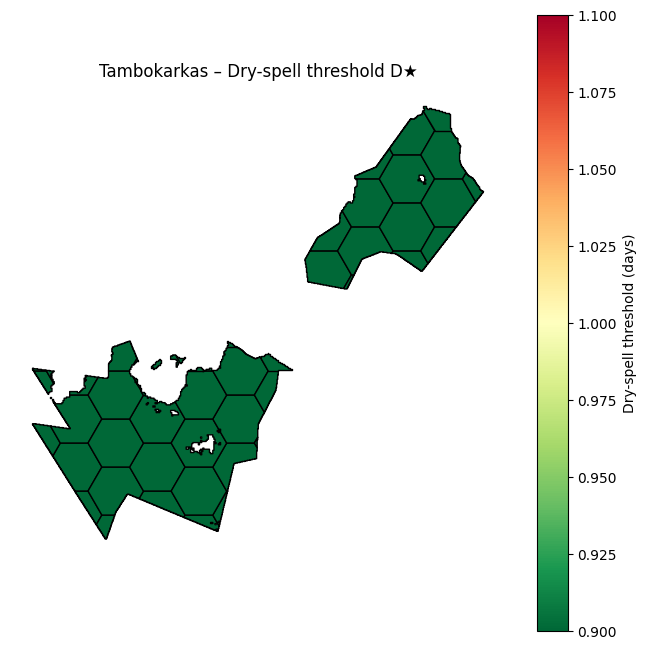

In [16]:
import geopandas as gpd, matplotlib.pyplot as plt
gdf = gpd.read_file(r'./outputs/rain_ndvi_hex/Tambokarkas_rain_ndvi_hex_alerts.gpkg')
fig, ax = plt.subplots(figsize=(8,8))
gdf.plot(column='Dstar_days', cmap='RdYlGn_r', legend=True, edgecolor='black',
         legend_kwds={'label':'Dry-spell threshold (days)'}, ax=ax)
ax.set_title('Tambokarkas – Dry-spell threshold D★')
plt.axis('off'); plt.show()

<Axes: >

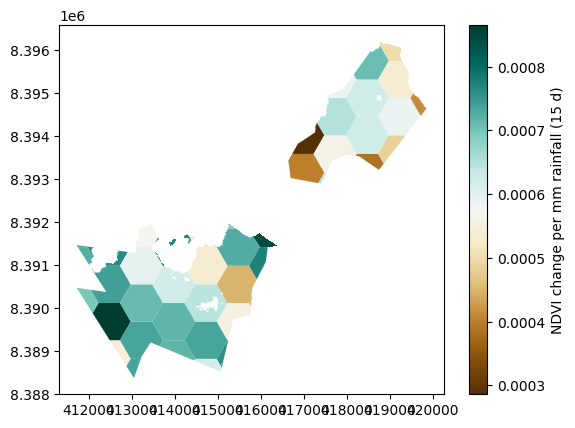

In [18]:
gdf.plot(column='RRC_ndvi_per_mm_15d', cmap='BrBG', legend=True,
         legend_kwds={'label':'NDVI change per mm rainfall (15 d)'})